In [1]:
from typing import Dict, Tuple
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import models, transforms
from torchvision.datasets import MNIST
from torchvision.utils import save_image, make_grid
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
import numpy as np

%matplotlib inline

from torch import autograd
from torch.autograd import Variable
from tensorboardX import SummaryWriter
import torch.optim as optim
import torchvision.datasets as datasets
import time
import os

if __name__ == "__main__":
    print("Torch version:", torch.__version__)
    print("CUDA available:", torch.cuda.is_available())
    print("CUDA version:", torch.version.cuda)
    print("Number of GPUs:", torch.cuda.device_count())
    print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.device_count() > 0 else "No GPU detected")

Torch version: 2.7.0+cu126
CUDA available: True
CUDA version: 12.6
Number of GPUs: 1
GPU name: NVIDIA GeForce RTX 4090


In [2]:
import importlib
import waveguide_dataset_paired_nonorm
importlib.reload(waveguide_dataset_paired_nonorm)
from waveguide_dataset_paired_nonorm import WaveguideDatasetPaired

h5_path='train_test_split.h5'
stats_path="waveguide_stats_log_norm_above90.npz"

train_ds = WaveguideDatasetPaired(h5_path, split="train", stats_path=stats_path)
test_ds  = WaveguideDatasetPaired(h5_path, split="test",  stats_path=stats_path)

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=True, num_workers=2, pin_memory=True)

In [3]:
class CombinedModeWeightNet(nn.Module):
    def __init__(self, mode_model, weight_model):
        super().__init__()
        self.mode_model = mode_model
        self.weight_model = weight_model

    def forward(self, x_img, x_cond):
        mode = self.mode_model(x_img, x_cond)   # [B, 1]
        weight = self.weight_model(x_img, x_cond)  # [B, 1]
        return torch.cat((mode, weight), dim=1)   # [B, 2]

from only_mode_only_weight_v3 import No_normal_modewieght_net

device = 'cuda' if torch.cuda.is_available() else 'cpu'

mode0_model = No_normal_modewieght_net().to(device)
weight0_model = No_normal_modewieght_net().to(device)

mode0_model.load_state_dict(torch.load('models/only_first_mode_no_normalization_with_less_dropout.pth', map_location=torch.device(device)))
weight0_model.load_state_dict(torch.load('models/only_first_weight_no_normalization_with_less_dropout_100.pth', map_location=torch.device(device)))

cnn = CombinedModeWeightNet(mode0_model, weight0_model).to(device)
cnn.eval()

CombinedModeWeightNet(
  (mode_model): No_normal_modewieght_net(
    (conv1): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (gn1): GroupNorm(8, 64, eps=1e-05, affine=True)
    (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (gn2): GroupNorm(8, 128, eps=1e-05, affine=True)
    (conv3): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (gn3): GroupNorm(8, 256, eps=1e-05, affine=True)
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (conv4): Conv2d(260, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (gn4): GroupNorm(8, 256, eps=1e-05, affine=True)
    (conv5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (gn5): GroupNorm(8, 256, eps=1e-05, affine=True)
    (conv6): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (gn6): GroupNorm(8, 256, eps=1e-05, affine=True)
    (conv7): Conv2d(256, 256, kernel_size=(3, 3),

In [4]:
# import os
# import h5py
# import numpy as np
# from typing import Iterable, Tuple, Optional
# from tqdm import tqdm
# import torch

# # ------------------------- utilities -------------------------

# def copy_attrs(src_obj, dst_obj):
#     for k, v in src_obj.attrs.items():
#         dst_obj.attrs[k] = v

# def iter_datasets(grp: h5py.Group, prefix="") -> Iterable[Tuple[str, h5py.Dataset]]:
#     for k, v in grp.items():
#         full = f"{prefix}/{k}" if prefix else k
#         if isinstance(v, h5py.Group):
#             yield from iter_datasets(v, full)
#         elif isinstance(v, h5py.Dataset):
#             yield full, v

# def create_like(out_group, name, shape, dtype, src: h5py.Dataset):
#     """Create a dataset in out_group named `name` with same filters/chunking as src."""
#     return out_group.create_dataset(
#         name,
#         shape=shape,
#         dtype=dtype,
#         chunks=src.chunks,
#         compression=src.compression,
#         compression_opts=src.compression_opts,
#         shuffle=getattr(src, "shuffle", None),
#         fletcher32=getattr(src, "fletcher32", False),
#         scaleoffset=getattr(src, "scaleoffset", None),
#     )

# def ensure_nchw(x: np.ndarray) -> np.ndarray:
#     """
#     Accept [N,H,W] or [N,1,H,W] or [N,C,H,W]; return [N,1,H,W] (pick C=0 if C>1).
#     (No value scaling—just shape handling.)
#     """
#     if x.ndim == 3:
#         N, H, W = x.shape
#         return x.reshape(N, 1, H, W)
#     elif x.ndim == 4:
#         if x.shape[1] == 1:
#             return x
#         # pick channel 0 if multi-channel
#         return x[:, :1, ...]
#     else:
#         raise ValueError(f"Unsupported pattern shape {x.shape}; expected [N,H,W] or [N,1,H,W] or [N,C,H,W].")

# def extract_mode_weight(y: torch.Tensor):
#     """
#     CNN output handler:
#       - If last dim == 2 → [mode, weight]
#       - If last dim >= 5 → use indices 0 (mode0) and 4 (weight0)
#     """
#     D = y.shape[-1]
#     if D == 2:
#         return y[..., 0], y[..., 1]
#     if D >= 5:
#         return y[..., 0], y[..., 4]
#     raise ValueError(f"CNN output last-dim {D} not supported (expect 2 or ≥5).")

# # ------------------------- main routine -------------------------

# def make_predicted_h5_with_param_overrides(
#     src_path: str,
#     dst_path: str,
#     cnn,                          # your loaded model
#     device: str = "cuda",
#     batch_size: int = 1024,
#     # dataset names (override if your file uses different ones)
#     pattern_train_key: str = "pattern_train",
#     pattern_test_key:  str = "pattern_test",
#     params_train_key:  str = "params_train",
#     params_test_key:   str = "params_test",
#     # where to store predictions
#     mode_train_key:    str = "mode_pred_train",
#     weight_train_key:  str = "weight_pred_train",
#     mode_test_key:     str = "mode_pred_test",
#     weight_test_key:   str = "weight_pred_test",
#     # param overrides (0-based indices 2 and 3)
#     idx2_value: float = 3.45,
#     idx3_value: float = 1.46,
# ):
#     """
#     Create a new H5 file identical to src, except:
#       - params_* datasets have indices 2 and 3 set to the provided constants
#       - new datasets with CNN predictions are added:
#            mode_pred_{train,test}, weight_pred_{train,test}
#     """
#     assert os.path.exists(src_path), f"not found: {src_path}"

#     cnn.eval()
#     device = torch.device(device)

#     with h5py.File(src_path, "r") as fin, h5py.File(dst_path, "w") as fout:
#         # Copy file-level attrs
#         copy_attrs(fin, fout)

#         # First mirror the group structure and copy all datasets as-is
#         # We'll overwrite/replace params_* and add prediction datasets afterward.
#         def mirror_groups(src_grp: h5py.Group, dst_grp: h5py.Group):
#             copy_attrs(src_grp, dst_grp)
#             for name, item in src_grp.items():
#                 if isinstance(item, h5py.Group):
#                     new_grp = dst_grp.create_group(name)
#                     mirror_groups(item, new_grp)
#                 elif isinstance(item, h5py.Dataset):
#                     src_ds = item
#                     dst_ds = create_like(dst_grp, name, src_ds.shape, src_ds.dtype, src_ds)
#                     copy_attrs(src_ds, dst_ds)
#                     # byte-for-byte copy of data
#                     dst_ds[...] = src_ds[...]
#                 else:
#                     raise RuntimeError(f"Unknown HDF5 object at {src_grp.name}/{name}")

#         mirror_groups(fin, fout)

#         # Helper to get (pattern_dset, params_dset) by name, raising if missing
#         def fetch_pair(pattern_key: str, params_key: str) -> Tuple[h5py.Dataset, h5py.Dataset]:
#             if pattern_key not in fin or params_key not in fin:
#                 # Try to search in case they are nested
#                 avail = dict(iter_datasets(fin))
#                 patt = [k for k in avail if k.endswith(pattern_key) or k.split("/")[-1] == pattern_key]
#                 par  = [k for k in avail if k.endswith(params_key)  or k.split("/")[-1] == params_key]
#                 if not patt or not par:
#                     raise KeyError(f"Could not locate datasets '{pattern_key}' and/or '{params_key}' in {src_path}")
#                 p_key = patt[0]; q_key = par[0]
#                 print(f"[info] resolved '{pattern_key}' -> '{p_key}', '{params_key}' -> '{q_key}'")
#                 return fin[p_key], fin[q_key]
#             return fin[pattern_key], fin[params_key]

#         # Process both splits
#         for split_name, patt_key, par_key, m_key, w_key in [
#             ("train", pattern_train_key, params_train_key, mode_train_key,  weight_train_key),
#             ("test",  pattern_test_key,  params_test_key,  mode_test_key,   weight_test_key),
#         ]:
#             print(f"\nProcessing split: {split_name}")
#             patt_src, par_src = fetch_pair(patt_key, par_key)
#             patt_dst = fout[patt_src.name]  # already copied 1:1
#             par_dst  = fout[par_src.name]

#             # Sanity checks
#             if par_src.shape[-1] < 4:
#                 raise ValueError(f"{par_src.name} last dimension < 4; cannot set indices 2 and 3.")
#             # Write overridden params into the *destination* dataset
#             # (We stream in chunks to avoid loading everything if large.)
#             N = par_src.shape[0] if par_src.ndim >= 2 else par_src.shape[0]
#             par_dtype = par_src.dtype

#             # Create prediction datasets mirroring params' filter settings
#             mode_ds = create_like(par_dst.parent, m_key, (N,), np.float32, par_dst)
#             weight_ds = create_like(par_dst.parent, w_key, (N,), np.float32, par_dst)
#             mode_ds.attrs["generated_by"] = "cnn"
#             weight_ds.attrs["generated_by"] = "cnn"
#             mode_ds.attrs["params_override_idxs_2_3"] = True
#             weight_ds.attrs["params_override_idxs_2_3"] = True
#             mode_ds.attrs["idx2_value"] = float(idx2_value)
#             mode_ds.attrs["idx3_value"] = float(idx3_value)
#             weight_ds.attrs["idx2_value"] = float(idx2_value)
#             weight_ds.attrs["idx3_value"] = float(idx3_value)

#             # Iterate in batches: read patterns + params, override params, run CNN, write back
#             # Try to align batch size with chunks
#             bs = max(1, batch_size)
#             total = N
#             with tqdm(total=total, desc=f"Predicting {split_name}", unit="item") as pbar:
#                 for start in range(0, N, bs):
#                     end = min(start + bs, N)

#                     # Read patterns (support [N,H,W] or [N,1,H,W] or [N,C,H,W])
#                     patt_np = patt_src[start:end, ...]
#                     patt_np = np.asarray(patt_np)  # actual numpy array
#                     patt_nchw = ensure_nchw(patt_np)  # [B,1,H,W]
#                     B, _, H, W = patt_nchw.shape

#                     # Read params and override indices 2 and 3
#                     par_np = np.asarray(par_src[start:end, ...])  # [B,4...]
#                     par_np = par_np.copy()  # we'll edit in place
#                     par_np[..., 2] = idx2_value
#                     par_np[..., 3] = idx3_value

#                     # Write the overridden params back into the destination file
#                     par_dst[start:end, ...] = par_np.astype(par_dtype, copy=False)

#                     # Prepare tensors for cnn (no clamping or scaling from this script)
#                     x = torch.from_numpy(patt_nchw).to(device=device, dtype=torch.float32)
#                     p = torch.from_numpy(par_np).to(device=device, dtype=torch.float32)

#                     with torch.no_grad():
#                         y = cnn(x, p)  # [B, D]
#                         mode_t, weight_t = extract_mode_weight(y)  # [B], [B]

#                     # Move preds to numpy and write
#                     mode_ds[start:end]   = mode_t.detach().cpu().numpy().astype(np.float32, copy=False)
#                     weight_ds[start:end] = weight_t.detach().cpu().numpy().astype(np.float32, copy=False)

#                     pbar.update(end - start)

#         print(f"\nDone. Wrote: {dst_path}")

# # ------------------------- example usage -------------------------
# # Provide your loaded cnn and device. This does not alter the source file.
# #
# make_predicted_h5_with_param_overrides(
#     src_path="train_test_split.h5",
#     dst_path="fixed_material_dataset.h5",
#     cnn=cnn,
#     device="cuda" if torch.cuda.is_available() else "cpu",
#     batch_size=1024,
#     # If your dataset keys differ, set them here:
#     pattern_train_key="pattern_train",
#     pattern_test_key="pattern_test",
#     params_train_key="params_train",
#     params_test_key="params_test",
# )


In [7]:
import os
import h5py
import numpy as np
from typing import Iterable, Tuple
from tqdm import tqdm
import torch

# ------------------------- utilities -------------------------

def copy_attrs(src_obj, dst_obj):
    for k, v in src_obj.attrs.items():
        dst_obj.attrs[k] = v

def iter_datasets(grp: h5py.Group, prefix="") -> Iterable[Tuple[str, h5py.Dataset]]:
    for k, v in grp.items():
        full = f"{prefix}/{k}" if prefix else k
        if isinstance(v, h5py.Group):
            yield from iter_datasets(v, full)
        elif isinstance(v, h5py.Dataset):
            yield full, v

def ensure_nchw(x: np.ndarray) -> np.ndarray:
    """
    Accept [N,H,W] or [N,1,H,W] or [N,C,H,W]; return [N,1,H,W] (take channel 0 if C>1).
    No resizing or value scaling—just shape handling.
    """
    if x.ndim == 3:
        N, H, W = x.shape
        return x.reshape(N, 1, H, W)
    elif x.ndim == 4:
        if x.shape[1] == 1:
            return x
        return x[:, :1, ...]
    else:
        raise ValueError(f"Unsupported pattern shape {x.shape}; expected [N,H,W] or [N,1,H,W] or [N,C,H,W].")

def extract_mode_weight(y: torch.Tensor):
    """
    CNN output handler:
      - If last dim == 2 → [mode, weight]
      - If last dim >= 5 → use indices 0 (mode0) and 4 (weight0)
    """
    D = y.shape[-1]
    if D == 2:
        return y[..., 0], y[..., 1]
    if D >= 5:
        return y[..., 0], y[..., 4]
    raise ValueError(f"CNN output last-dim {D} not supported (expect 2 or ≥5).")

def _chunks_like_params_for_grid(params_ds: h5py.Dataset, new_shape):
    """
    Preserve storage layout as closely as HDF5 allows:
      - If params_ds is contiguous (chunks=None), return None (contiguous).
      - If params_ds is chunked with (cN, cP) and new_shape is (N, W, P=4),
        use (cN, 1, cP) so the item-axis chunk is identical and P-axis matches.
    """
    if params_ds.chunks is None:
        return None
    src_chunks = params_ds.chunks
    if len(src_chunks) == 2 and len(new_shape) == 3:
        cN, cP = src_chunks
        N, W, P = new_shape
        return (min(cN, N), min(1, W), min(cP, P))
    return tuple(min(sc, sh) for sc, sh in zip(src_chunks, new_shape[:len(src_chunks)]))

def create_grid_dataset_like_params(parent_grp: h5py.Group,
                                    name: str,
                                    shape,
                                    dtype,
                                    src_params: h5py.Dataset):
    """Create a dataset under parent_grp using EXACT same filters as src_params.
    Chunking is derived via _chunks_like_params_for_grid to keep item-axis chunks identical.
    """
    chunks = _chunks_like_params_for_grid(src_params, shape)
    return parent_grp.create_dataset(
        name,
        shape=shape,
        dtype=dtype,
        chunks=chunks,
        compression=src_params.compression,
        compression_opts=src_params.compression_opts,
        shuffle=getattr(src_params, "shuffle", None),
        fletcher32=getattr(src_params, "fletcher32", False),
        scaleoffset=getattr(src_params, "scaleoffset", None),
    )

# ------------------------- main routine -------------------------

def make_predicted_h5_wavelength_grid_exact_filters(
    src_path: str,
    dst_path: str,
    cnn,                          # your loaded model: forward(x, params) -> [..., D]
    device: str = "cuda",
    batch_size_items: int = 256,  # number of *items* per outer batch
    w_chunk: int = 10,            # number of wavelengths per inner forward pass
    # dataset names in the source file
    pattern_train_key: str = "pattern_train",
    pattern_test_key:  str = "pattern_test",
    params_train_key:  str = "params_train",
    params_test_key:   str = "params_test",
    # wavelength grid config
    lambda_min: float = 1.3,
    lambda_max: float = 1.6,
    num_wavelengths: int = 100,
    # param rules
    lattice_norm_const: float = 0.4,  # param[1] = lattice_norm_const / wavelength
    atom_index_val: float = 3.45,     # param[2]
    substrate_index_val: float = 1.46 # param[3]
):
    """
    Mirrors the source file exactly and adds:
      wavelengths               : [W]
      params_grid_{train,test}  : [N, W, 4]
      mode_pred_grid_{train..}  : [N, W]
      weight_pred_grid_{train..}: [N, W]

    Patterns are copied byte-for-byte; **only the CNN input** is quartered to 32×32.
    """
    assert os.path.exists(src_path), f"not found: {src_path}"

    cnn.eval()
    device = torch.device(device)

    wavelengths = np.linspace(lambda_min, lambda_max, num_wavelengths, dtype=np.float32)

    with h5py.File(src_path, "r") as fin, h5py.File(dst_path, "w") as fout:
        copy_attrs(fin, fout)

        def mirror_groups(src_grp: h5py.Group, dst_grp: h5py.Group):
            copy_attrs(src_grp, dst_grp)
            for name, item in src_grp.items():
                if isinstance(item, h5py.Group):
                    new_grp = dst_grp.create_group(name)
                    mirror_groups(item, new_grp)
                elif isinstance(item, h5py.Dataset):
                    dst_ds = dst_grp.create_dataset(
                        name,
                        shape=item.shape,
                        dtype=item.dtype,
                        chunks=item.chunks,
                        compression=item.compression,
                        compression_opts=item.compression_opts,
                        shuffle=getattr(item, "shuffle", None),
                        fletcher32=getattr(item, "fletcher32", False),
                        scaleoffset=getattr(item, "scaleoffset", None),
                    )
                    copy_attrs(item, dst_ds)
                    dst_ds[...] = item[...]
                else:
                    raise RuntimeError(f"Unknown HDF5 object at {src_grp.name}/{name}")

        mirror_groups(fin, fout)

        wl_ds = fout.create_dataset("wavelengths", data=wavelengths, dtype=np.float32)
        wl_ds.attrs["units"] = "micron"
        wl_ds.attrs["lambda_min"] = float(lambda_min)
        wl_ds.attrs["lambda_max"] = float(lambda_max)
        wl_ds.attrs["num_wavelengths"] = int(num_wavelengths)

        def fetch_pair(pattern_key: str, params_key: str) -> Tuple[h5py.Dataset, h5py.Dataset]:
            if pattern_key not in fin or params_key not in fin:
                avail = dict(iter_datasets(fin))
                patt = [k for k in avail if k.endswith(pattern_key) or k.split("/")[-1] == pattern_key]
                par  = [k for k in avail if k.endswith(params_key)  or k.split("/")[-1] == params_key]
                if not patt or not par:
                    raise KeyError(f"Could not locate datasets '{pattern_key}' and/or '{params_key}' in {src_path}")
                p_key = patt[0]; q_key = par[0]
                print(f"[info] resolved '{pattern_key}' -> '{p_key}', '{params_key}' -> '{q_key}'")
                return fin[p_key], fin[q_key]
            return fin[pattern_key], fin[params_key]

        printed_debug_shapes = False

        for split_name, patt_key, par_key in [
            ("train", pattern_train_key, params_train_key),
            ("test",  pattern_test_key,  params_test_key),
        ]:
            print(f"\nProcessing split: {split_name}")
            patt_src, par_src = fetch_pair(patt_key, par_key)
            par_dtype = par_src.dtype

            parent_out = fout[par_src.parent.name]
            N = patt_src.shape[0]
            W = num_wavelengths

            params_grid_ds  = create_grid_dataset_like_params(
                parent_out, f"params_grid_{split_name}", (N, W, 4), par_dtype, par_src
            )
            mode_grid_ds    = create_grid_dataset_like_params(
                parent_out, f"mode_pred_grid_{split_name}", (N, W), np.float32, par_src
            )
            weight_grid_ds  = create_grid_dataset_like_params(
                parent_out, f"weight_pred_grid_{split_name}", (N, W), np.float32, par_src
            )

            for ds in (params_grid_ds, mode_grid_ds, weight_grid_ds):
                ds.attrs["grid_type"] = "wavelength_sweep"
                ds.attrs["wavelengths_dataset"] = "/wavelengths"
                ds.attrs["param_fields"] = np.array(
                    ["wavelength", "lattice_norm", "atom_index", "substrate_index"],
                    dtype="S16"
                )

            bs_items = max(1, batch_size_items)
            wc = max(1, min(w_chunk, W))

            with tqdm(total=N, desc=f"Predicting {split_name}", unit="item") as pbar:
                for start in range(0, N, bs_items):
                    end = min(start + bs_items, N)
                    B = end - start

                    # --------- READ PATTERNS (no edits to file) ----------
                    patt_np = np.asarray(patt_src[start:end, ...])
                    patt_nchw = ensure_nchw(patt_np)  # [B,1,H,W] (H=W=64 for your file)

                    # Quarter *for CNN input only* (crop top-left 32x32)
                    H, Wimg = patt_nchw.shape[-2], patt_nchw.shape[-1]
                    if H < 32 or Wimg < 32:
                        raise ValueError(f"Pattern too small to quarter: found {(H, Wimg)} in '{patt_src.name}'")
                    patt_nchw_q = patt_nchw[:, :, :32, :32]   # [B,1,32,32]

                    # --------- BUILD PARAM GRID ----------
                    params_grid_batch = np.empty((B, W, 4), dtype=par_dtype)
                    params_grid_batch[..., 0] = wavelengths[None, :].astype(par_dtype, copy=False)                       # λ
                    params_grid_batch[..., 1] = (lattice_norm_const / wavelengths)[None, :].astype(par_dtype, copy=False) # 0.4/λ
                    params_grid_batch[..., 2] = np.full((B, W), atom_index_val, dtype=par_dtype)                          # n_atom
                    params_grid_batch[..., 3] = np.full((B, W), substrate_index_val, dtype=par_dtype)                      # n_sub

                    mode_grid_batch   = np.empty((B, W), dtype=np.float32)
                    weight_grid_batch = np.empty((B, W), dtype=np.float32)

                    # --------- EVALUATE IN WAVELENGTH MINI-BATCHES ----------
                    for w_start in range(0, W, wc):
                        w_end = min(w_start + wc, W)
                        w_count = w_end - w_start

                        par_chunk = params_grid_batch[:, w_start:w_end, :]   # [B, w_count, 4]
                        par_flat  = par_chunk.reshape(B * w_count, 4)        # [B*w_count, 4]

                        patt_rep = np.repeat(patt_nchw_q, repeats=w_count, axis=0)  # [B*w_count, 1, 32, 32]

                        # To torch (float32), no scaling
                        x = torch.from_numpy(patt_rep).to(device=device, dtype=torch.float32)
                        p = torch.from_numpy(par_flat).to(device=device, dtype=torch.float32)

                        if not printed_debug_shapes:
                            print("CNN input shapes → x:", tuple(x.shape), "p:", tuple(p.shape))
                            printed_debug_shapes = True
                        assert x.ndim == 4 and x.shape[1] == 1 and x.shape[2] == 32 and x.shape[3] == 32, \
                            f"Bad x shape to CNN: {tuple(x.shape)} (expected [*,1,32,32])"
                        assert p.ndim == 2 and p.shape[1] == 4, \
                            f"Bad p shape to CNN: {tuple(p.shape)} (expected [*,4])"

                        with torch.inference_mode():
                            y = cnn(x, p)  # [B*w_count, D]
                            mode_t, weight_t = extract_mode_weight(y)

                        mode_block   = mode_t.detach().cpu().numpy().astype(np.float32, copy=False).reshape(B, w_count)
                        weight_block = weight_t.detach().cpu().numpy().astype(np.float32, copy=False).reshape(B, w_count)
                        mode_grid_batch[:,   w_start:w_end] = mode_block
                        weight_grid_batch[:, w_start:w_end] = weight_block

                    # --------- WRITE OUT ----------
                    params_grid_ds[start:end, :, :] = params_grid_batch
                    mode_grid_ds[start:end,   :]    = mode_grid_batch
                    weight_grid_ds[start:end, :]    = weight_grid_batch

                    pbar.update(B)

        print(f"\nDone. Wrote: {dst_path}")

# ------------------------- example usage -------------------------
make_predicted_h5_wavelength_grid_exact_filters(
    src_path="train_test_split.h5",
    dst_path="wavelength_grid_dataset.h5",
    cnn=cnn,
    device="cuda" if torch.cuda.is_available() else "cpu",
    batch_size_items=256,
    w_chunk=10,
    pattern_train_key="pattern_train",
    pattern_test_key="pattern_test",
    params_train_key="params_train",
    params_test_key="params_test",
    lambda_min=1.3,
    lambda_max=1.6,
    num_wavelengths=100,
    lattice_norm_const=0.4,
    atom_index_val=3.45,
    substrate_index_val=1.46,
)



Processing split: train


Predicting train:   0%|          | 0/1113998 [00:00<?, ?item/s]

CNN input shapes → x: (2560, 1, 32, 32) p: (2560, 4)


Predicting train: 100%|██████████| 1113998/1113998 [1:01:18<00:00, 302.81item/s]



Processing split: test


Predicting test: 100%|██████████| 477427/477427 [25:05<00:00, 317.13item/s]


Done. Wrote: wavelength_grid_dataset.h5



=== H5 CONTENTS ===
wavelength_grid_dataset.h5 (root)
  [DATASET] mode_pred_grid_test  shape=(477427, 100)  dtype=float32
  [DATASET] mode_pred_grid_train  shape=(1113998, 100)  dtype=float32
  [DATASET] neff_test  shape=(477427, 4)  dtype=float64
  [DATASET] neff_train  shape=(1113998, 4)  dtype=float64
  [DATASET] params_grid_test  shape=(477427, 100, 4)  dtype=float64
  [DATASET] params_grid_train  shape=(1113998, 100, 4)  dtype=float64
  [DATASET] params_test  shape=(477427, 4)  dtype=float64
  [DATASET] params_train  shape=(1113998, 4)  dtype=float64
  [DATASET] pattern_test  shape=(477427, 64, 64)  dtype=int16
  [DATASET] pattern_train  shape=(1113998, 64, 64)  dtype=int16
  [DATASET] wavelengths  shape=(100,)  dtype=float32
  [DATASET] weight_pred_grid_test  shape=(477427, 100)  dtype=float32
  [DATASET] weight_pred_grid_train  shape=(1113998, 100)  dtype=float32
  [DATASET] weight_test  shape=(477427, 4)  dtype=float64
  [DATASET] weight_train  shape=(1113998, 4)  dtype=float6

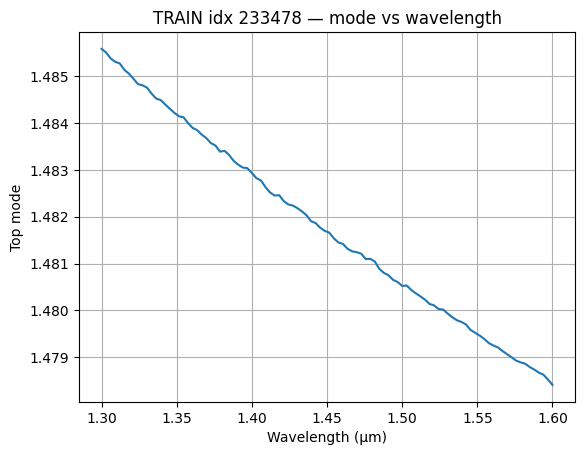

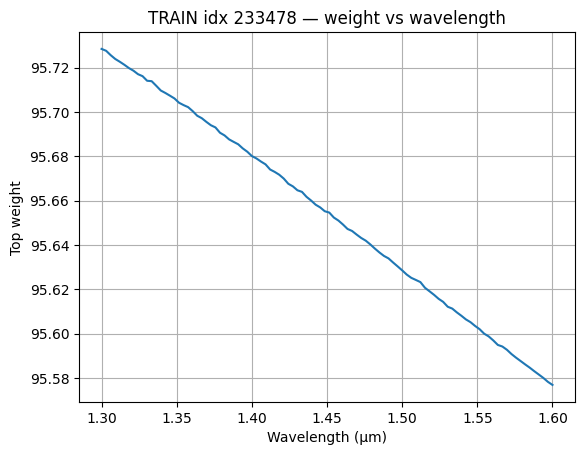

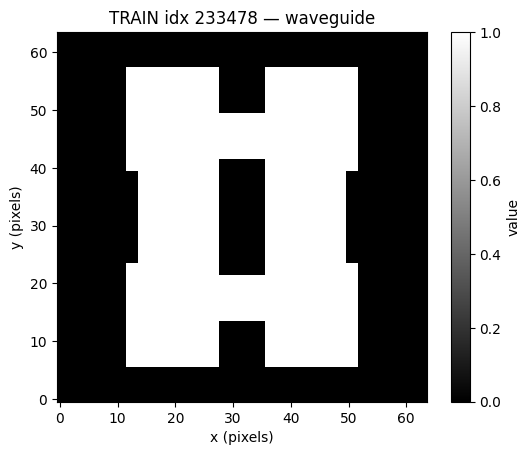

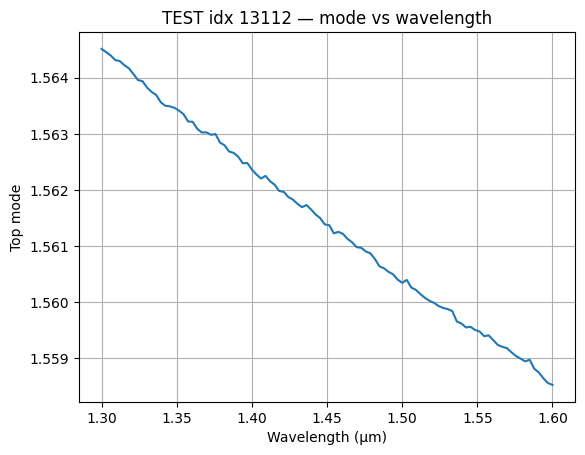

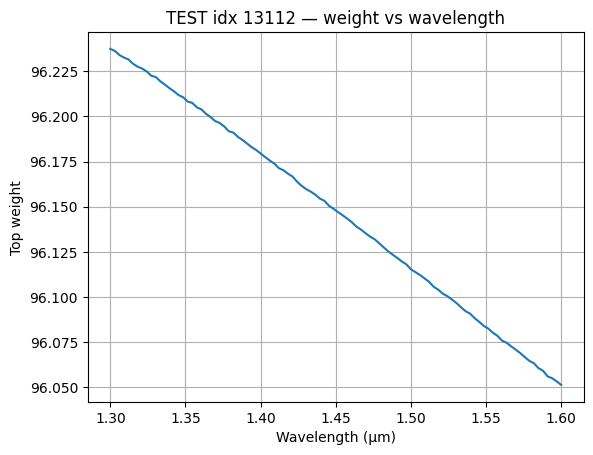

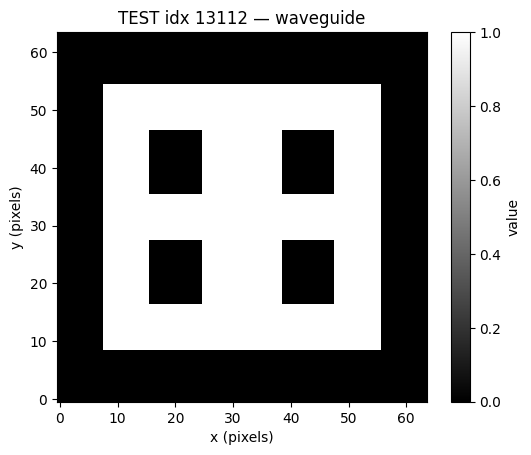

In [9]:
import h5py
import numpy as np
import random
from typing import Dict, Optional
import matplotlib.pyplot as plt  # NEW

# --------- Utilities ---------

def walk_h5(obj, prefix=""):
    """
    Recursively print the HDF5 tree with dataset shapes/dtypes.
    """
    if isinstance(obj, h5py.File):
        print(f"{obj.filename} (root)")
        for k, v in obj.items():
            walk_h5(v, k)
    elif isinstance(obj, h5py.Group):
        print(f"[GROUP] {prefix}/")
        for k, v in obj.items():
            walk_h5(v, f"{prefix}/{k}" if prefix else k)
    elif isinstance(obj, h5py.Dataset):
        print(f"  [DATASET] {prefix}  shape={obj.shape}  dtype={obj.dtype}")
    else:
        print(f"  [UNKNOWN] {prefix}")

def list_all_datasets(f: h5py.File) -> Dict[str, h5py.Dataset]:
    """
    Return dict of {full_path: dataset}.
    """
    out = {}
    def _recur(g, p=""):
        for k, v in g.items():
            full = f"{p}/{k}" if p else k
            if isinstance(v, h5py.Group):
                _recur(v, full)
            elif isinstance(v, h5py.Dataset):
                out[full] = v
    _recur(f)
    return out

def find_dataset(f: h5py.File, name: str) -> Optional[str]:
    """
    Find dataset by exact path or by basename matching `name`.
    Returns the full path or None.
    """
    if name in f:
        return name
    all_sets = list_all_datasets(f)
    matches = [full for full in all_sets if full.split("/")[-1] == name]
    if matches:
        return matches[0]
    return None

def ensure_hw(slice_like: np.ndarray) -> np.ndarray:
    """
    Accept [H,W], [1,H,W], or [C,H,W]; return [H,W] (take channel 0 if present).
    """
    if slice_like.ndim == 2:
        return slice_like
    if slice_like.ndim == 3:
        return slice_like[0]  # first channel
    raise ValueError(f"Unexpected array rank for pattern slice: {slice_like.shape}")

def get_length_from_pattern(d: h5py.Dataset) -> int:
    """
    Infer number of items N from a pattern dataset with shape [N,H,W] or [N,1,H,W] or [N,C,H,W].
    If dataset is 2D, treat N=1.
    """
    if d.ndim == 2:
        return 1
    return d.shape[0]

def get_item_pattern(d: h5py.Dataset, idx: int) -> np.ndarray:
    """
    Return a 2D array [H,W] for item idx from pattern dataset.
    Supports [N,H,W], [N,1,H,W], [N,C,H,W], and [H,W] (singleton).
    """
    if d.ndim == 2:
        return ensure_hw(d[...])
    if d.ndim == 3:
        return ensure_hw(d[idx, ...])
    if d.ndim == 4:
        return ensure_hw(d[idx, ...])
    raise ValueError(f"Unsupported pattern dataset rank: {d.ndim}")

def get_item_params_grid(d: h5py.Dataset, idx: int) -> np.ndarray:
    """
    Return per-item param grid [W, 4] from params_grid_* with shape [N, W, 4].
    """
    if d.ndim != 3 or d.shape[-1] != 4:
        raise ValueError(f"Expected params_grid_* with shape [N, W, 4], got {d.shape}")
    return np.array(d[idx, ...])

def get_item_vector(d: h5py.Dataset, idx: int) -> np.ndarray:
    """
    Return per-item vector [W] from mode_pred_grid_* or weight_pred_grid_* with shape [N, W].
    """
    if d.ndim != 2:
        raise ValueError(f"Expected grid dataset with shape [N, W], got {d.shape}")
    return np.array(d[idx, ...])

def pretty_print_item_grid(split: str,
                           idx: int,
                           wavelengths: np.ndarray,
                           pattern: np.ndarray,
                           params_grid: np.ndarray,   # [W,4]
                           mode_vec: Optional[np.ndarray],   # [W]
                           weight_vec: Optional[np.ndarray]  # [W]
                           ):
    """
    Print all values for one item: wavelengths, param grid [W,4], pattern matrix, and prediction vectors.
    Also prints a small summary (peak weight λ and corresponding mode).
    """
    print(f"\n========== {split.upper()} ITEM @ index {idx} ==========")

    # Wavelengths
    print("\nWavelengths [W] (micron):")
    with np.printoptions(suppress=False, linewidth=120, threshold=np.inf):
        print(wavelengths)

    # Param grid
    print("\nParams grid [W,4] columns = [wavelength, lattice_norm, atom_index, substrate_index]:")
    with np.printoptions(suppress=False, linewidth=160, threshold=np.inf):
        print(params_grid)

    # Pattern
    print("\nPattern [H, Wimg] matrix (all values, first channel if multi-channel in source):")
    with np.printoptions(suppress=False, linewidth=160, threshold=np.inf):
        print(pattern)

    # Predictions
    if mode_vec is not None:
        print(f"\nmode_pred_grid_{split} [W]:")
        with np.printoptions(suppress=False, linewidth=160, threshold=np.inf):
            print(mode_vec)
    else:
        print(f"\nmode_pred_grid_{split}: <not found>")

    if weight_vec is not None:
        print(f"\nweight_pred_grid_{split} [W]:")
        with np.printoptions(suppress=False, linewidth=160, threshold=np.inf):
            print(weight_vec)

        # Small summary: peak weight
        peak_idx = int(np.argmax(weight_vec))
        peak_lambda = float(wavelengths[peak_idx])
        peak_weight = float(weight_vec[peak_idx])
        peak_mode = float(mode_vec[peak_idx]) if mode_vec is not None else float('nan')
        print(f"\nSummary: peak weight at λ={peak_lambda:.6g} → weight={peak_weight:.6g}, mode={peak_mode:.6g}")
    else:
        print(f"\nweight_pred_grid_{split}: <not found>")

# ---------- NEW: plotting helper ----------

def plot_item_grid(split: str,
                   idx: int,
                   wavelengths: np.ndarray,
                   pattern: np.ndarray,
                   mode_vec: Optional[np.ndarray],
                   weight_vec: Optional[np.ndarray]):
    """
    Create three figures:
      1) mode vs wavelength
      2) weight vs wavelength
      3) waveguide image
    """
    # 1) mode vs wavelength
    if mode_vec is not None:
        plt.figure()
        plt.plot(wavelengths, mode_vec)
        plt.xlabel("Wavelength (μm)")
        plt.ylabel("Top mode")
        plt.title(f"{split.upper()} idx {idx} — mode vs wavelength")
        plt.grid(True)

    # 2) weight vs wavelength
    if weight_vec is not None:
        plt.figure()
        plt.plot(wavelengths, weight_vec)
        plt.xlabel("Wavelength (μm)")
        plt.ylabel("Top weight")
        plt.title(f"{split.upper()} idx {idx} — weight vs wavelength")
        plt.grid(True)

    # 3) waveguide image
    plt.figure()
    plt.imshow(pattern, origin="lower", cmap="gray", interpolation="nearest")
    plt.title(f"{split.upper()} idx {idx} — waveguide")
    plt.xlabel("x (pixels)")
    plt.ylabel("y (pixels)")
    plt.colorbar(label="value")

# --------- Main inspection function ---------

def inspect_wavelength_grid_h5(
    h5_path: str,
    # base pattern keys (unchanged from source file)
    pattern_train_key: str = "pattern_train",
    pattern_test_key:  str = "pattern_test",
    # new grid keys
    wavelengths_key: str = "wavelengths",
    params_grid_train_key: str = "params_grid_train",
    params_grid_test_key:  str = "params_grid_test",
    mode_grid_train_key:   str = "mode_pred_grid_train",
    weight_grid_train_key: str = "weight_pred_grid_train",
    mode_grid_test_key:    str = "mode_pred_grid_test",
    weight_grid_test_key:  str = "weight_pred_grid_test",
    seed: Optional[int] = None,
    show_plots: bool = True,   # NEW
):
    """
    For the wavelength-sweep dataset layout:
      - wavelengths                 : [W]
      - params_grid_{train,test}    : [N, W, 4]  (wavelength, lattice_norm, atom_index, substrate_index)
      - mode_pred_grid_{train,test} : [N, W]
      - weight_pred_grid_{train,test}: [N, W]
      - pattern_{train,test}        : [N, H, Wimg] or [N,1,H,Wimg] or [N,C,H,Wimg] (unchanged)

    Prints the tree and inspects one random TRAIN and TEST item.
    Also plots: (mode vs λ), (weight vs λ), and the waveguide.
    """
    rng = random.Random(seed)

    with h5py.File(h5_path, "r") as f:
        print("\n=== H5 CONTENTS ===")
        walk_h5(f)

        # Resolver that raises on missing
        def res_or_die(name: str) -> str:
            path = find_dataset(f, name)
            if path is None:
                raise KeyError(f"Dataset '{name}' not found anywhere in {h5_path}")
            return path

        # Resolve datasets
        wl_path  = res_or_die(wavelengths_key)
        patt_tr_path = res_or_die(pattern_train_key)
        patt_te_path = res_or_die(pattern_test_key)
        par_grid_tr_path  = res_or_die(params_grid_train_key)
        par_grid_te_path  = res_or_die(params_grid_test_key)
        mode_grid_tr_path   = find_dataset(f, mode_grid_train_key)
        weight_grid_tr_path = find_dataset(f, weight_grid_train_key)
        mode_grid_te_path   = find_dataset(f, mode_grid_test_key)
        weight_grid_te_path = find_dataset(f, weight_grid_test_key)

        wl = np.array(f[wl_path], dtype=float)
        patt_tr = f[patt_tr_path]; patt_te = f[patt_te_path]
        par_grid_tr = f[par_grid_tr_path]; par_grid_te = f[par_grid_te_path]

        N_train = get_length_from_pattern(patt_tr)
        N_test  = get_length_from_pattern(patt_te)
        idx_train = rng.randrange(N_train)
        idx_test  = rng.randrange(N_test)

        # TRAIN item
        pattern_tr     = get_item_pattern(patt_tr, idx_train)
        params_grid_tr = get_item_params_grid(par_grid_tr, idx_train)
        mode_vec_tr    = get_item_vector(f[mode_grid_tr_path], idx_train) if mode_grid_tr_path else None
        weight_vec_tr  = get_item_vector(f[weight_grid_tr_path], idx_train) if weight_grid_tr_path else None
        pretty_print_item_grid("train", idx_train, wl, pattern_tr, params_grid_tr, mode_vec_tr, weight_vec_tr)
        if show_plots:
            plot_item_grid("train", idx_train, wl, pattern_tr, mode_vec_tr, weight_vec_tr)

        # TEST item
        pattern_te     = get_item_pattern(patt_te, idx_test)
        params_grid_te = get_item_params_grid(par_grid_te, idx_test)
        mode_vec_te    = get_item_vector(f[mode_grid_te_path], idx_test) if mode_grid_te_path else None
        weight_vec_te  = get_item_vector(f[weight_grid_te_path], idx_test) if weight_grid_te_path else None
        pretty_print_item_grid("test", idx_test, wl, pattern_te, params_grid_te, mode_vec_te, weight_vec_te)
        if show_plots:
            plot_item_grid("test", idx_test, wl, pattern_te, mode_vec_te, weight_vec_te)

        if show_plots:
            plt.show()

# --------------- Example usage ---------------
inspect_wavelength_grid_h5("wavelength_grid_dataset.h5", seed=42, show_plots=True)
